In [ ]:
import os, sys, importlib, pathlib
import pandas as pd
from pathlib import Path
sys.path.append (os.path.abspath(".."))

import statsmodels.api as sm
import statsmodels.formula.api as smf


# my utils
from utils import fa
from utils import modeling
from utils import preprocess_listings
from utils.preprocess_listings import desc_catORnum
from utils import modeling_did


# 标准版存档V0：

LABELS_EN=[
            'open to different cultures', 'cosmopolitan','international view', 'cultural exchange',
            'personal life', 'life experiences', 'divers interests', 'hobbies', 'enjoy life',
            'meet new people', 'welcoming', 'friendly', 'sociable', 'interpersonal interaction',
            'thoughtful service', 'attentive to needs', 'willing to help', 'responsive',
            'fan of Airbnb', 'Airbnb community','love Airbnb', 'travel with Airbnb'
        ]
DICT_FACTOR_ITEMS={"ouverture":['open to different cultures', 'cosmopolitan','international view', 'cultural exchange'],
                   "authenticité":['personal life', 'life experiences', 'divers interests', 'hobbies', 'enjoy life'],
                   "sociabilité":['meet new people', 'welcoming', 'friendly', 'sociable', 'interpersonal interaction'],
                   "auto_promotion":['thoughtful service', 'attentive to needs', 'willing to help', 'responsive'],
                   "exemplarité":['fan of Airbnb', 'Airbnb community','love Airbnb', 'travel with Airbnb']}

tactics_bio=[
    "ouverture", "authenticité","sociabilité","auto_promotion","exemplarité", 
]
def p_to_sig(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    elif p < 0.1: return '.'
    else: return ''

In [ ]:
# path_df="../data_processed\listings_tactics_bio_vis-paris_london-2306_2406_ols.csv"
path_df=r"../data_processed\listings_tactics_bio_vis-paris_london-2306_2312_2406.csv"
df_all=pd.read_csv(path_df)
print(df_all.shape)

C:\Users\yeliu\AppData\Local\Temp\ipykernel_13004\571702545.py:3: DtypeWarning: Columns (6,68,115) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all=pd.read_csv(path_df)


(266852, 125)


In [ ]:
df_all[tactics_bio]=df_all[tactics_bio].fillna(0)
df_all["host_picture_type"]=df_all["host_picture_type"].fillna("no_person")

print(df_all[tactics_bio].isna().value_counts())
print(df_all["host_picture_type"].isna().value_counts())


ouverture  authenticité  sociabilité  auto_promotion  exemplarité
False      False         False        False           False          266852
Name: count, dtype: int64
host_picture_type
False    266852
Name: count, dtype: int64


In [ ]:
# df_all["time"]=df_all["time"].astype(str)
# df_all['trend'] = df_all['time'].map({'2306':0, "2312":1, '2406':2})#***
print(df_all[['in_paris',"time","trend","post"]].value_counts(dropna=False))
print(df_all['time'].dtype)
df_all['time']=df_all['time'].astype(str)

in_paris  time  trend  post
1         2406  2      1       62738
0         2406  2      1       49856
          2312  1      0       43172
          2306  0      0       42356
1         2312  1      0       35829
          2306  0      0       32901
Name: count, dtype: int64
int64


In [ ]:
# df_all.to_csv(path_df, index=False)

## pre trend check

In [5]:
df_pre=df_all[df_all['time']!="2406"]
print(df_pre.shape)
print(df_pre[['time','in_paris']].value_counts())

(266852, 125)
time  in_paris
2406  1           62738
      0           49856
2312  0           43172
2306  0           42356
2312  1           35829
2306  1           32901
Name: count, dtype: int64


In [147]:
## pre trend check!!!

# booking_rate_l90d
df=df_pre.copy()
formula= (" booking_rate_l90d ~ C(host_identity_verified)  + review_scores_rating + has_rating + number_of_reviews_ltm +"
            "C(host_is_superhost) +"
            "years_since_host + professional_host + "
            "host_response_rate + C(host_response_time)+ "
            "has_text + lang_fr + lang_en + text_length +"
            "price  + availability_90 + C(room_type) + C(instant_bookable) + "
            "in_paris * C(time)"
)
model=smf.ols(formula, data=df).fit(cov_type="HC1")#robust standard errors
summary=model.summary()
print(summary)


                            OLS Regression Results                            
Dep. Variable:      booking_rate_l90d   R-squared:                       0.398
Model:                            OLS   Adj. R-squared:                  0.398
Method:                 Least Squares   F-statistic:                     2802.
Date:                Tue, 07 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:54:56   Log-Likelihood:                 88109.
No. Observations:              266852   AIC:                        -1.762e+05
Df Residuals:                  266824   BIC:                        -1.759e+05
Df Model:                          27                                         
Covariance Type:                  HC1                                         
                                                  coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

# tactic~


## + trend: "C(time) + in_paris*trend + in_paris * post"


In [ ]:

# ✔ 1. C(time) # 控制所有城市共同的时间变化（宏观趋势）
# ✔ 2. in_paris * trend # 允许 Paris 和 London 有不同的趋势（解决你发现的不平行问题）
# ✔ 3. in_paris * post # 👉 在控制趋势差异之后，识别 JO 的“额外冲击”

# 在控制了城市固定差异、时间效应以及城市特定趋势（city-specific trends）之后，
# in_paris × post 捕捉了 2024年巴黎奥运会 对 Paris 相对于 London 的“额外变化”（differential change）

# 优点： 清晰、好解释（有一个系数）
# 缺点： 强结构假设的 DiD（parametric DiD）：
# pre-trend 是线性的
# treatment effect 是“一个跳跃 + 一个趋势修正”


In [ ]:

def run_tactic_model_by_trend(df, y):
    formula= (f"{y} ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
            "number_of_reviews_ltm + "
            "C(host_is_superhost) +"
            "years_since_host + professional_host + "
            "host_response_rate +  C(host_response_time)+"
            "has_text + lang_en + lang_fr + text_length+"
            "price  + availability_90 + C(room_type) + C(instant_bookable) + "
            
            # "ouverture + authenticité + sociabilité + auto_promotion + exemplarité +"
            # "C(host_picture_type) +"
            # "pic_no_person + pic_pro_style + pic_life_style +"
            # " is_smiling + "
            # "C(age_class) + C(gender) +"
            "C(time) + in_paris*trend + in_paris * post"
    )
    model_tactic=smf.ols(formula, data=df).fit()
    # summary=model_tactic.summary()
    # print(summary)
    return model_tactic


results=[]
for var in tactics_bio:
    print(var)
    model=run_tactic_model_by_trend(df, var)
    term="in_paris:post"
    coef = model.params[term]
    se = model.bse[term]
    pval = model.pvalues[term]
    
    results.append({
        "variable": var,
        "coef": coef,
        "se": se,
        "pval": pval,
        "sig": p_to_sig(pval),
        "ci_low": coef - 1.96 * se,
        "ci_high": coef + 1.96 * se
    })
results_df = pd.DataFrame(results)


ouverture
authenticité
sociabilité
auto_promotion
exemplarité


In [45]:
results_df

,variable,coef,se,pval,sig,ci_low,ci_high
0,ouverture,-0.009624,0.010803,0.373031,,-0.030798,0.011551
1,authenticité,-0.015611,0.011191,0.163017,,-0.037545,0.006323
2,sociabilité,-0.009865,0.011565,0.393671,,-0.032532,0.012803
3,auto_promotion,0.042751,0.010544,0.000050,***,0.022086,0.063417
4,exemplarité,0.044509,0.011202,0.000071,***,0.022553,0.066464


<Figure size 640x480 with 0 Axes>

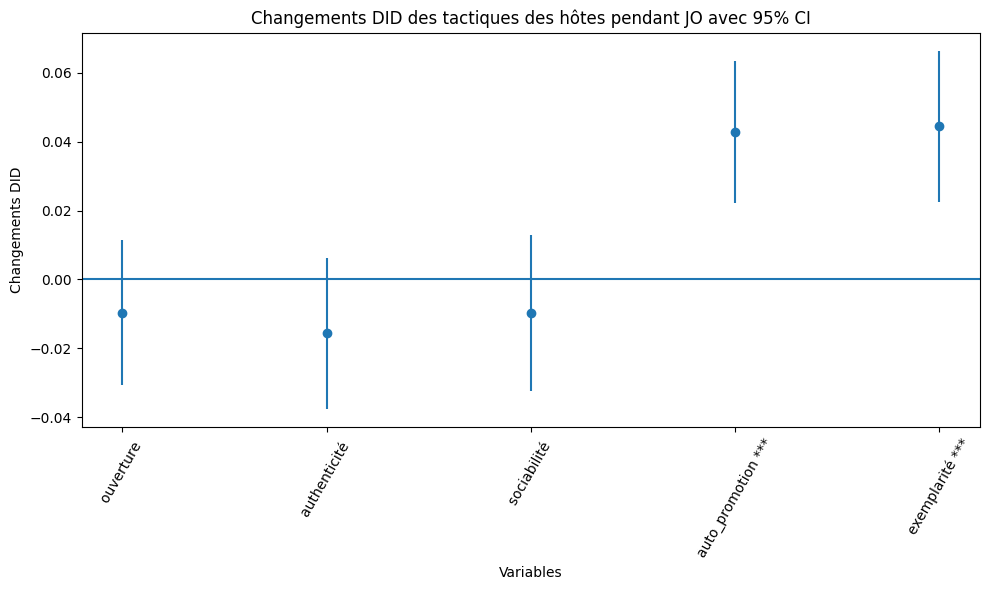

In [46]:
# did effect
import pandas as pd
import matplotlib.pyplot as plt

results_df['label']=results_df['variable']+" "+results_df['sig']

plt.figure()
plt.figure(figsize=(10,6))
plt.errorbar(
    results_df["label"],
    results_df["coef"],
    yerr=[results_df["coef"] - results_df["ci_low"],
          results_df["ci_high"] - results_df["coef"]],
    fmt='o', 
)
plt.axhline(0)  # 0线（是否显著）
plt.xlabel("Variables")
plt.ylabel("Changements DID")
plt.title("Changements DID des tactiques des hôtes pendant JO avec 95% CI")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

## event study :C(time) + in_paris * C(time)


In [ ]:
## event study :C(time) + in_paris * C(time)
# 不假设差异趋势是线性的
# # 弱假设 / 非参数 DiD（event study）：[更加稳健]
# 每个时间点可以自由变化,不强制趋势形状
##==允许：2312 下跌，2406 反弹，不规则变化

# C(time)固定时间变化（季节，整体增长）
# 交互项：paris(相对于london)[在每个时间点]的额外变化

# | 时间   | Paris 相对 London 的差异 |
# | ---- | ------------------- |
# | 2306 | baseline（被省略）     |
# | 2312 | β₁（pre-trend）       |
# | 2406 | β₂（JO + trend）      |
# JO effect ≈ β_2406 - β_2312 (24差异减去稳定差异==jo额外差异)

# 线性组合计算β_2406 - β_2312 = 0 ?


##结果差异，不仅因为数据不稳定，还有模型假设的差异

In [38]:

importlib.reload(modeling_did)
from utils.modeling_did import run_tactic_model_by_time


df=df_all.copy()
model_tactic=run_tactic_model_by_time(df, y="authenticité")
print(model_tactic.summary())

                            OLS Regression Results                            
Dep. Variable:           authenticité   R-squared:                       0.169
Model:                            OLS   Adj. R-squared:                  0.169
Method:                 Least Squares   F-statistic:                     2007.
Date:                Thu, 09 Apr 2026   Prob (F-statistic):               0.00
Time:                        09:11:15   Log-Likelihood:            -2.6399e+05
No. Observations:              266852   AIC:                         5.280e+05
Df Residuals:                  266824   BIC:                         5.283e+05
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                                                  coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

In [ ]:
# event study 图：Paris 相对于 London，在不同时间点的“动态差异路径”

importlib.reload(modeling_did)
from utils.modeling_did import get_event_study_data, get_ddd_effect

var="authenticité"
data=get_event_study_data(model_tactic, var=var)
display(data)

ddd=get_ddd_effect(model, var=var)
display(ddd)




,time,coef,ci_low,ci_high,variable,se,pval,sig,label
0,2306,0.000000,0.000000,0.000000,authenticité,NaN,NaN,,2306
1,2312,0.029654,0.016556,0.042753,authenticité,0.006683,9.113254e-06,***,2312 ***
2,2406,0.043697,0.031511,0.055884,authenticité,0.006218,2.099537e-12,***,2406 ***


,variable,coef,se,pval,sig,ci_low,ci_high
0,authenticité,0.024492,0.006112,0.000061,***,0.012512,0.036471


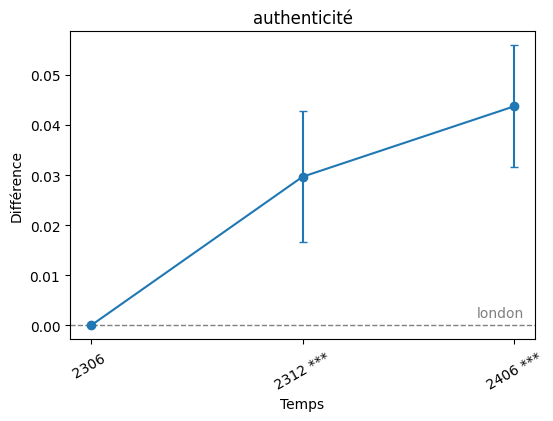

In [56]:

    
importlib.reload(modeling_did)
from utils.modeling_did import get_event_study_data, get_ddd_effect, run_tactic_model_by_time, plot_one_did

plot_one_did(data_all,axes=None, var='authenticité')

In [22]:
df=df_all.copy()
data_list=[]
for i, y in enumerate(tactics_bio):
    # if i >1:
    #     break  
    print (i, y)
    model=run_tactic_model_by_time(df, y)
    data = get_event_study_data(model, var=y)
    data_list.append(data)
data_all=pd.concat(data_list, axis=0)
data_all

0 ouverture
1 authenticité
2 sociabilité
3 auto_promotion
4 exemplarité


,time,coef,ci_low,ci_high,variable,se,pval,sig,label
0,2306,0.000000,0.000000,0.000000,ouverture,NaN,NaN,,2306
1,2312,0.005668,-0.006977,0.018313,ouverture,0.006452,3.796275e-01,,2312
2,2406,0.001713,-0.010052,0.013477,ouverture,0.006002,7.753645e-01,,2406
0,2306,0.000000,0.000000,0.000000,authenticité,NaN,NaN,,2306
1,2312,0.029654,0.016556,0.042753,authenticité,0.006683,9.113254e-06,***,2312 ***
2,2406,0.043697,0.031511,0.055884,authenticité,0.006218,2.099537e-12,***,2406 ***
0,2306,0.000000,0.000000,0.000000,sociabilité,NaN,NaN,,2306
1,2312,0.022324,0.008787,0.035861,sociabilité,0.006906,1.228010e-03,**,2312 **
2,2406,0.034783,0.022189,0.047377,sociabilité,0.006426,6.193342e-08,***,2406 ***
0,2306,0.000000,0.000000,0.000000,auto_promotion,NaN,NaN,,2306


C:\Users\yeliu\AppData\Local\Temp\ipykernel_6184\3956810171.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\yeliu\AppData\Local\Temp\ipykernel_6184\3956810171.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


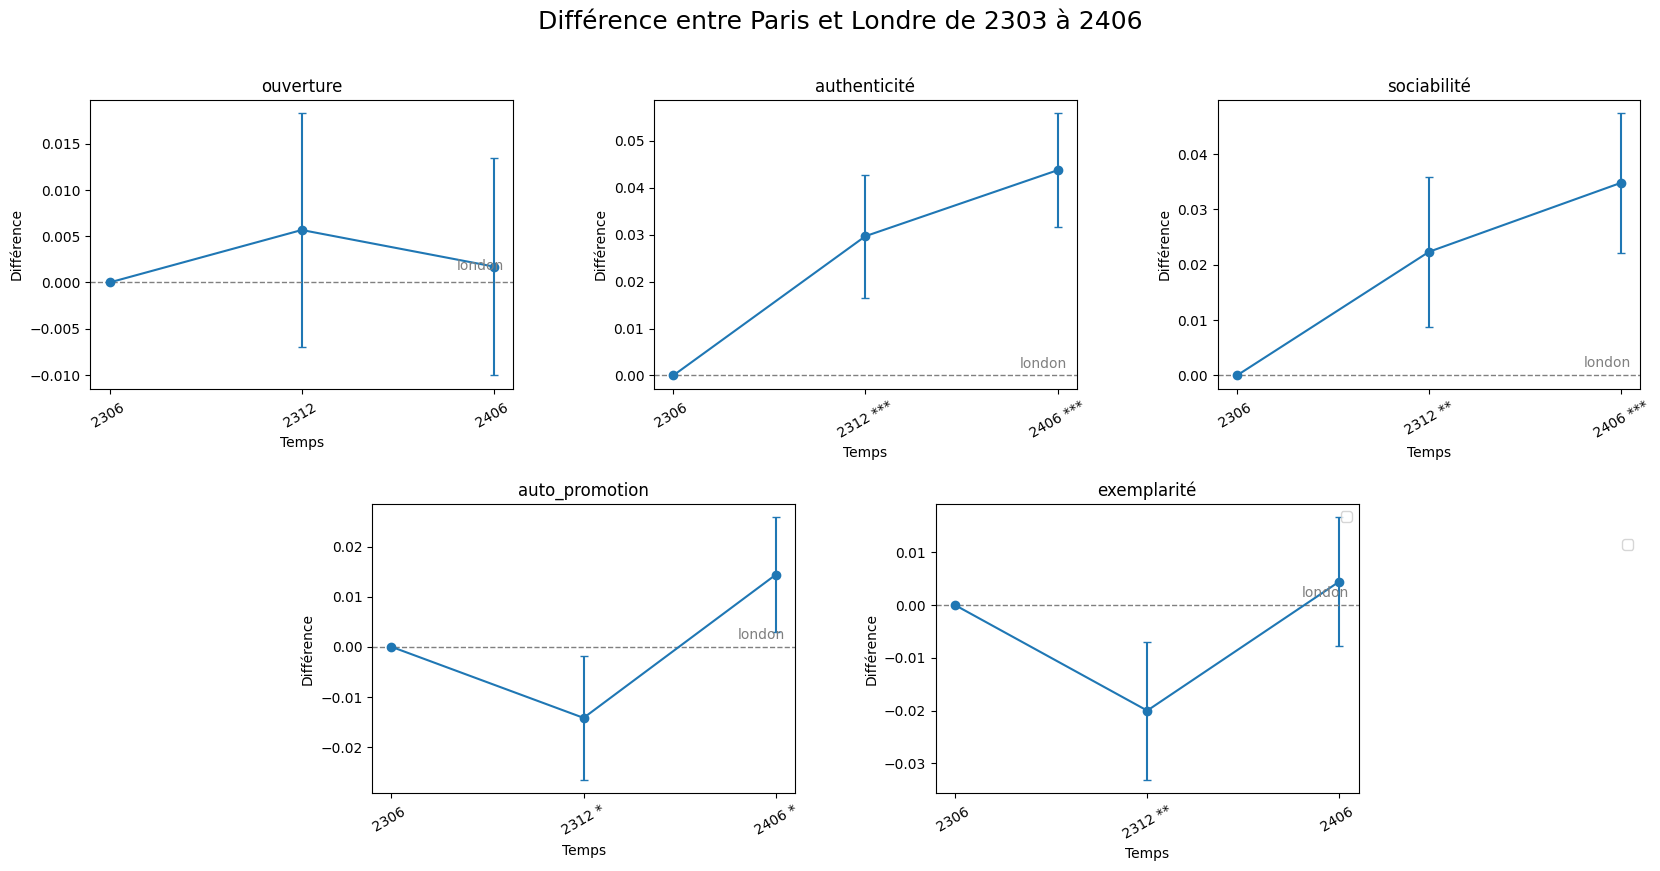

In [57]:
 
importlib.reload(modeling_did)
from utils.modeling_did import get_event_study_data, get_ddd_effect, run_tactic_model_by_time, plot_one_did

## plot
# --------------------layout-------------------
# 使用更细的列分辨率（2 行 × 6 列），方便把第二行两个图放在中间列
fig = plt.figure(figsize=(20,9))# sharey=True
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.4, wspace=1)

axes = []
# 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])
axes.extend([ax1, ax2, ax3])

# 第二行两个：让它们居中，分别占中间的两列 (1:3 和 3:5)
ax4 = fig.add_subplot(gs[1, 1:3])
ax5 = fig.add_subplot(gs[1, 3:5])
axes.extend([ax4, ax5])

# 确保 tactics_vars 长度为 5（或小于等于 len(axes)）
n_to_plot = min(len(tactics_bio), len(axes))


for i, var in enumerate(tactics_bio):
    plot_one_did(data=data_all, axes=axes, i=i, var=var)
fig.suptitle(
        "Différence entre Paris et Londre de 2303 à 2406",
        fontsize=18,
        y=0.98
    )


handles, labels =axes[0].get_legend_handles_labels()
fig.legend(
    handles, 
    labels,
    loc="upper right", # 图例的“右上角”对齐到某个位置
    bbox_to_anchor=(0.9, 0.4) #(x,y),“把图例的右上角，对齐到 (0.9, 0.4) 这个点”
) 
plt.legend()
plt.tight_layout()
plt.show()

# 在event study，不对趋势形状做任何假设，如果不存在jo，我们认为2406的差异和2312一样，两个点处于一条水平线上
# 所以jo的效应偏离这条差异水平线
# 如果trend是线性的，2406没有jo的差异会落在延长线上，表示两地的差异不断扩大

### predict line+ counterfactual line

In [67]:
df=df_all.copy()
y='authenticité'
model=run_tactic_model_by_time(df, y)


In [79]:
ddd=get_ddd_effect(model, var=y)
display(ddd)

,variable,coef,se,pval,sig,ci_low,ci_high
0,authenticité,0.014043,0.006106,0.021454,*,0.002076,0.026011


ddd of authenticité: 0.024491717931886266


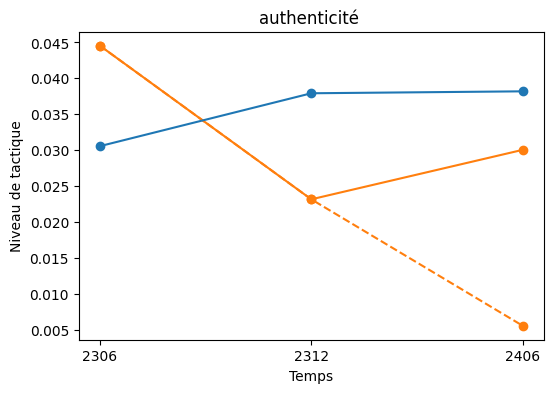

In [121]:
importlib.reload(modeling_did)
from utils.modeling_did import run_tactic_model_by_time,get_cf_data, plot_one_cf

var="authenticité"
agg=get_cf_data(df, model, var=var)
plot_one_cf(agg, axes=None, i=0, var=var)


Text(0.5, 0, 'Temps')

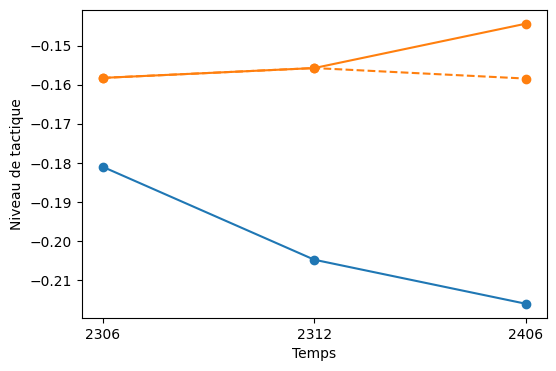

In [85]:

fig, ax=plt.subplots(figsize=(6, 4))
# categorical mapping
times = sorted(agg["time"].unique())
time_map = {t: i for i, t in enumerate(times)}

paris = agg[agg["in_paris"] == 1]    
ax.plot(
    paris["time"].map(time_map),
    paris["y_hat"],
    marker="o",
    label="Observed (Paris)",
        color='tab:orange'
)

ax.plot(
    paris["time"].map(time_map),
    paris["y_cf"],
    marker="o",
    linestyle="--",
    label="Counterfactual  (Paris)",
    color='tab:orange'
)

control = agg[agg["in_paris"] == 0]
ax.plot(
    control["time"].map(time_map),
    control["y_hat"],
    marker="o",
    # alpha=0.4,
    label="Observed (London)",
    color='tab:blue'
)

# event line
# ax.axvline(time_map[2406], color="red", linestyle="--")
# x-axis as labels (equal spacing!)
ax.set_xticks(list(time_map.values()))
ax.set_xticklabels(list(time_map.keys()))

# ax.legend()

# var_sig=p_to_sig(pval_dict.get(var))
# ax.set_title(f"{var} {var_sig}")
ax.set_ylabel("Niveau de tactique")
ax.set_xlabel("Temps")
# ax.set_ylabel("Outcome")
# break

In [97]:
importlib.reload(modeling_did)
from utils.modeling_did import run_tactic_model_by_time,get_cf_data, plot_one_cf

agg_list=[]
ddd_list=[]

for y in tactics_bio:
    print(y)
    df=df_all.copy()
    model=run_tactic_model_by_time(df, y)
    ddd=get_ddd_effect(model, var=y)
    agg=get_cf_data(df, model, var=y)
    ddd_list.append(ddd)
    agg_list.append(agg)
    # plot_one_cf(agg, axes=None, i=0, var=y)
df_ddd=pd.concat(ddd_list, axis=0)
df_agg=pd.concat(agg_list, axis=0)


ouverture
ddd of ouverture: -0.003955410205441894
authenticité
ddd of authenticité: 0.014043224391017566
sociabilité
ddd of sociabilité: 0.012459292106811095
auto_promotion
ddd of auto_promotion: 0.028563511199381705
exemplarité
ddd of exemplarité: 0.024491717931886266


In [98]:
display(df_agg)
display(df_ddd)


,time,in_paris,y_hat,y_cf,variable
0,2306,0,-0.111349,-0.111349,ouverture
1,2306,1,-0.093083,-0.093083,ouverture
2,2312,0,-0.111726,-0.111726,ouverture
3,2312,1,-0.083193,-0.083193,ouverture
4,2406,0,-0.113564,-0.113564,ouverture
5,2406,1,-0.088205,-0.084249,ouverture
0,2306,0,-0.181066,-0.181066,authenticité
1,2306,1,-0.158274,-0.158274,authenticité
2,2312,0,-0.204839,-0.204839,authenticité
3,2312,1,-0.155755,-0.155755,authenticité


,variable,coef,se,pval,sig,ci_low,ci_high
0,ouverture,-0.003955,0.005895,5.022069e-01,,-0.015509,0.007598
0,authenticité,0.014043,0.006106,2.145399e-02,*,0.002076,0.026011
0,sociabilité,0.012459,0.006310,4.832976e-02,*,0.000091,0.024827
0,auto_promotion,0.028564,0.005753,6.870991e-07,***,0.017288,0.039839
0,exemplarité,0.024492,0.006112,6.149051e-05,***,0.012512,0.036471


ouverture
authenticité
sociabilité
auto_promotion
exemplarité


C:\Users\yeliu\AppData\Local\Temp\ipykernel_6184\270545438.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1,1])


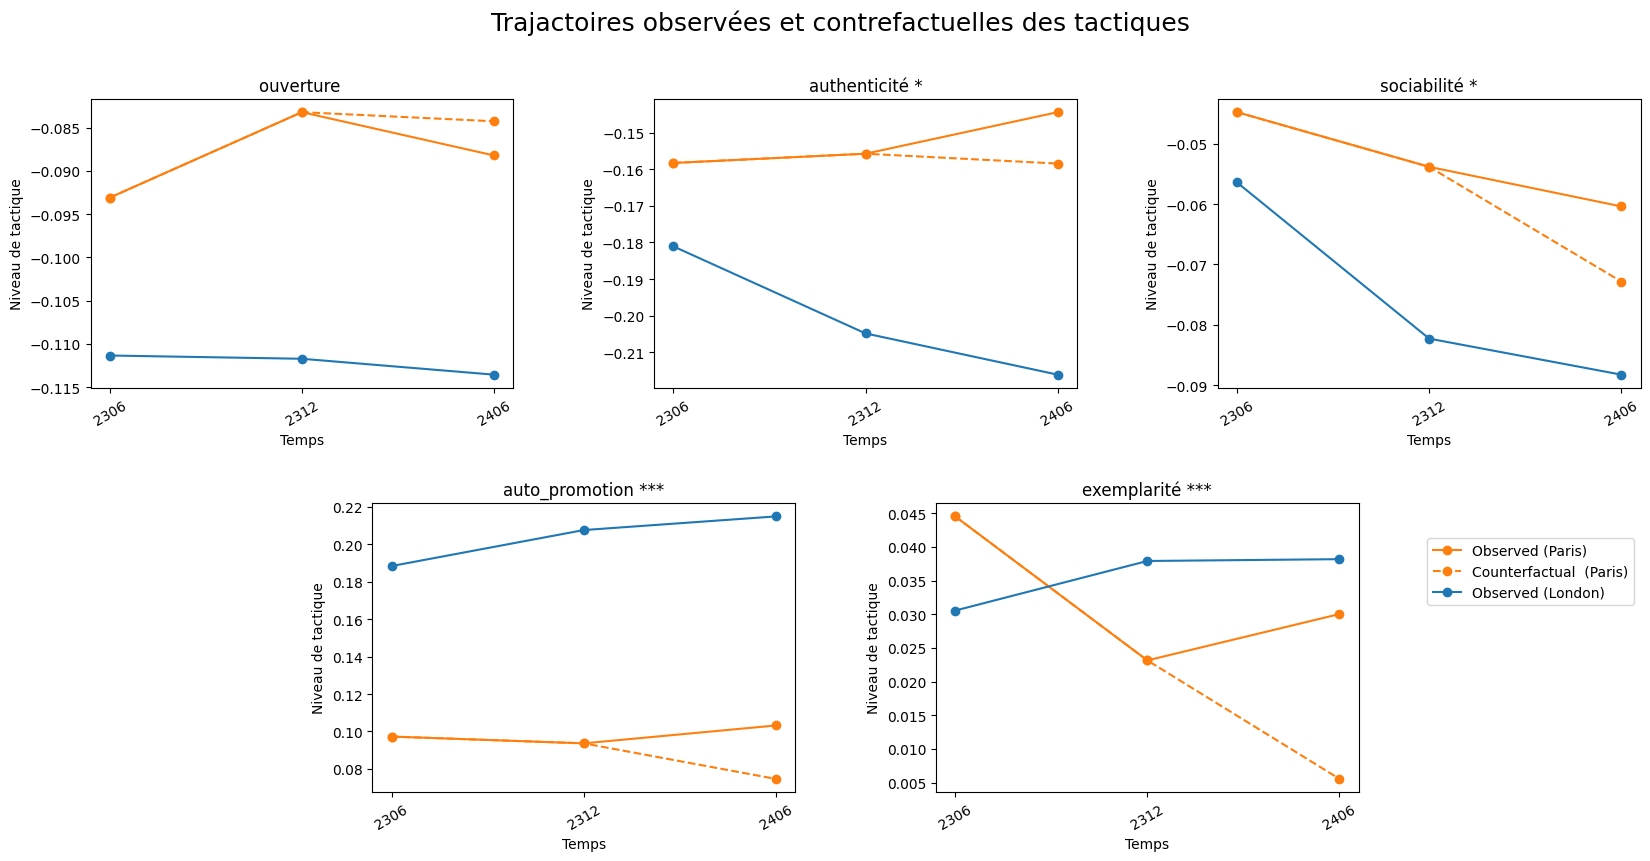

In [126]:
importlib.reload(modeling_did)
from utils.modeling_did import run_tactic_model_by_time,get_cf_data, plot_one_cf

# ---layout---
# 使用更细的列分辨率（2 行 × 6 列），方便把第二行两个图放在中间列
fig = plt.figure(figsize=(20,9))# sharey=True
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.4, wspace=1)

axes = []
# 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])
axes.extend([ax1, ax2, ax3])

# 第二行两个：让它们居中，分别占中间的两列 (1:3 和 3:5)
ax4 = fig.add_subplot(gs[1, 1:3])
ax5 = fig.add_subplot(gs[1, 3:5])
axes.extend([ax4, ax5])

# 确保 tactics_vars 长度为 5（或小于等于 len(axes)）
n_to_plot = min(len(tactics_bio), len(axes))


## plot:
for i, var in enumerate(tactics_bio):
    print(var)
    agg=df_agg[df_agg['variable']==var]
    ddd_sig=df_ddd[df_ddd['variable']==var]['sig'].loc[0]
    plot_one_cf(agg, axes=axes, i=i,  var=var, ddd_sig=ddd_sig)
    


# layout:
fig.suptitle(
        "Trajactoires observées et contrefactuelles des tactiques",
        fontsize=18,
        y=0.98
    )

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper right",
    # ncol=2
    bbox_to_anchor=(0.9,0.4)
)

plt.tight_layout(rect=[0, 0, 1,1])
plt.show()


## cat var

In [ ]:
porportion变化

# booking_rate~

In [ ]:
df[tactics_bio].isna().value_counts()
df['host_picture_type'].isna().value_counts()
df['host_picture_type'].value_counts(dropna=False)

host_picture_type
pro_style     94648
life_style    80969
no_person     79364
NaN           11871
Name: count, dtype: int64

In [ ]:

df=df_all.copy()
formula= ("booking_rate_l90d ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
        "number_of_reviews_ltm + "
        "C(host_is_superhost) +"
        "years_since_host + professional_host + "
        "host_response_rate +  C(host_response_time)+"
        "has_text + lang_en + lang_fr + text_length+"
        "price  + availability_90 + C(room_type) + C(instant_bookable) +"
        
        "ouverture + authenticité + sociabilité + auto_promotion + exemplarité +"
        "C(host_picture_type) +"
        "C(time) + in_paris*C(time)"
)
df=df_all.copy()
model_basic=smf.ols(formula, data=df).fit()
summary=model_basic.summary()
print(summary)


                            OLS Regression Results                            
Dep. Variable:      booking_rate_l90d   R-squared:                       0.399
Model:                            OLS   Adj. R-squared:                  0.399
Method:                 Least Squares   F-statistic:                     5209.
Date:                Thu, 09 Apr 2026   Prob (F-statistic):               0.00
Time:                        13:46:23   Log-Likelihood:                 88301.
No. Observations:              266852   AIC:                        -1.765e+05
Df Residuals:                  266817   BIC:                        -1.762e+05
Df Model:                          34                                         
Covariance Type:            nonrobust                                         
                                                  coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

In [180]:
var="booking_rate_l90d"
data_booking=get_event_study_data(model=model_basic, var=var)
display(data_booking)
print(data_booking.time.dtype)
ddd=get_ddd_effect(model, var=var)
ddd

,time,coef,ci_low,ci_high,variable,se,pval,sig,label
0,2306,0.000000,0.000000,0.000000,booking_rate_l90d,NaN,NaN,,2306
1,2312,-0.030423,-0.033922,-0.026924,booking_rate_l90d,0.001785,4.303327e-65,***,2312 ***
2,2406,-0.058139,-0.061395,-0.054884,booking_rate_l90d,0.001661,9.234794e-268,***,2406 ***


object
booking_rate_l90d


,variable,coef,se,pval,sig,ci_low,ci_high
0,booking_rate_l90d,-0.027794,0.001683,3.283887e-61,***,-0.031093,-0.024494


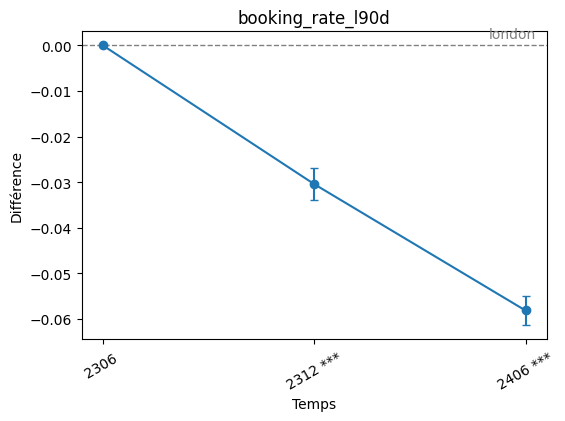

In [181]:
plot_one_did(data_booking, axes=None, i=0, var='booking_rate_l90d')

ddd of booking_rate_l90d: -0.027716668465284693


,time,in_paris,y_hat,y_cf,variable
0,2306,0,0.162585,0.162585,booking_rate_l90d
1,2306,1,0.213811,0.213811,booking_rate_l90d
2,2312,0,0.072095,0.072095,booking_rate_l90d
3,2312,1,0.102370,0.102370,booking_rate_l90d
4,2406,0,0.119446,0.119446,booking_rate_l90d
5,2406,1,0.076108,0.103825,booking_rate_l90d


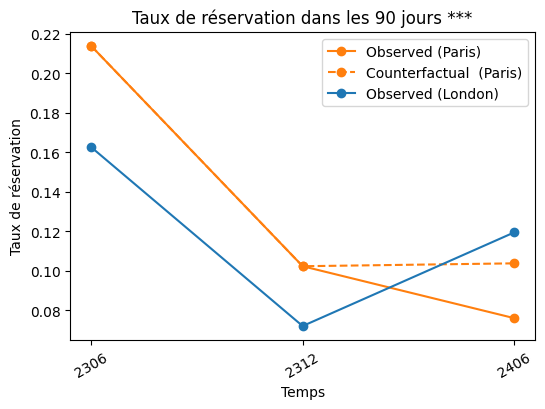

In [182]:
importlib.reload(modeling_did)
from utils.modeling_did import get_event_study_data, get_ddd_effect, run_tactic_model_by_time, plot_one

var="booking_rate_l90d"
agg_all=get_cf_data(df, model_basic, var=var)


fig, ax=plt.subplots(figsize=(6,4))
agg=agg_all[agg_all['variable']==var]
display(agg)


## plt
paris = agg[agg["in_paris"] == 1]    
# ---paris obs---
ax.plot(
    paris["time"],#.map(time_map),
    paris["y_hat"],
    marker="o",
    label="Observed (Paris)",
    color='tab:orange'
)


# ---paris cf---
ax.plot(
    paris["time"],#.map(time_map),
    paris["y_cf"],
    marker="o",
    linestyle="--",
    label="Counterfactual  (Paris)",
    color='tab:orange'
)

# ---london obs---
control = agg[agg["in_paris"] == 0]
ax.plot(
    control["time"],#.map(time_map),
    control["y_hat"],
    marker="o",
    # alpha=0.4,
    label="Observed (London)",
    color='tab:blue'
)

ax.set_title(f"Taux de réservation dans les 90 jours {ddd_sig}")
ax.set_ylabel("Taux de réservation")
ax.set_xlabel("Temps")
ax.tick_params(axis="x", rotation=30)
ax.legend()


## effets des tactiques

In [183]:
importlib.reload(modeling_did)
from utils.modeling_did import plot_predict_curve

pred_df= plot_predict_curve(model, df,  var="authenticité")
pred_df.head()

default_vals: {'host_identity_verified': 't', 'host_is_superhost': 'f', 'host_response_time': 'within an hour', 'room_type': 'Entire home/apt', 'instant_bookable': 'f', 'host_picture_type': 'pro_style', 'time': '2406', 'review_scores_rating': np.float64(4.735862013400686), 'has_rating': np.int64(1), 'number_of_reviews_ltm': np.float64(8.702947701347563), 'years_since_host': np.float64(6.897913450152144), 'professional_host': np.int64(0), 'host_response_rate': np.float64(0.7873780972224305), 'has_text': np.int64(0), 'lang_en': np.int64(0), 'lang_fr': np.int64(0), 'text_length': np.float64(31.178567145833647), 'price': np.float64(236.31068157630446), 'availability_90': np.float64(49.34868016728374), 'ouverture': np.float64(-0.10035002037640012), 'authenticité': np.float64(-0.1766306637850288), 'sociabilité': np.float64(-0.06570151372882968), 'auto_promotion': np.float64(0.1525097733332789), 'exemplarité': np.float64(0.03377935753765357), 'in_paris': np.int64(0)}


,host_identity_verified,host_is_superhost,host_response_time,room_type,instant_bookable,host_picture_type,time,review_scores_rating,has_rating,number_of_reviews_ltm,...,availability_90,ouverture,authenticité,sociabilité,auto_promotion,exemplarité,in_paris,y,low,high
0,t,f,within an hour,Entire home/apt,f,pro_style,2406,4.735862,1,8.702948,...,49.34868,-0.10035,-2.053085,-0.065702,0.15251,0.033779,0,0.135317,0.131169,0.139465
1,t,f,within an hour,Entire home/apt,f,pro_style,2406,4.735862,1,8.702948,...,49.34868,-0.10035,-2.014349,-0.065702,0.15251,0.033779,0,0.135410,0.131295,0.139526
2,t,f,within an hour,Entire home/apt,f,pro_style,2406,4.735862,1,8.702948,...,49.34868,-0.10035,-1.975614,-0.065702,0.15251,0.033779,0,0.135504,0.131420,0.139589
3,t,f,within an hour,Entire home/apt,f,pro_style,2406,4.735862,1,8.702948,...,49.34868,-0.10035,-1.936879,-0.065702,0.15251,0.033779,0,0.135598,0.131545,0.139651
4,t,f,within an hour,Entire home/apt,f,pro_style,2406,4.735862,1,8.702948,...,49.34868,-0.10035,-1.898144,-0.065702,0.15251,0.033779,0,0.135692,0.131669,0.139714


In [184]:
# def plot_predict_curve_fast(model, df, var, sample_n=5000):
#     import numpy as np
#     import pandas as pd

#     # ✅ 抽样
#     base = df.sample(sample_n, random_state=0).copy()

#     grid = np.linspace(df[var].min(), df[var].max(), 100)

#     pred_list = []

#     for val in grid:
#         base[var] = val
#         yhat = model.predict(base)   # 🚀 更快
#         pred_list.append(yhat.mean())

#     return pd.DataFrame({
#         var: grid,
#         "y": pred_list
#     })

default_vals: {'host_identity_verified': 't', 'host_is_superhost': 'f', 'host_response_time': 'within an hour', 'room_type': 'Entire home/apt', 'instant_bookable': 'f', 'host_picture_type': 'pro_style', 'time': '2406', 'review_scores_rating': np.float64(4.735862013400686), 'has_rating': np.int64(1), 'number_of_reviews_ltm': np.float64(8.702947701347563), 'years_since_host': np.float64(6.897913450152144), 'professional_host': np.int64(0), 'host_response_rate': np.float64(0.7873780972224305), 'has_text': np.int64(0), 'lang_en': np.int64(0), 'lang_fr': np.int64(0), 'text_length': np.float64(31.178567145833647), 'price': np.float64(236.31068157630446), 'availability_90': np.float64(49.34868016728374), 'ouverture': np.float64(-0.10035002037640012), 'authenticité': np.float64(-0.1766306637850288), 'sociabilité': np.float64(-0.06570151372882968), 'auto_promotion': np.float64(0.1525097733332789), 'exemplarité': np.float64(0.03377935753765357), 'in_paris': np.int64(0)}
default_vals: {'host_iden

C:\Users\yeliu\AppData\Local\Temp\ipykernel_6184\3721209017.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()#on ax
C:\Users\yeliu\AppData\Local\Temp\ipykernel_6184\3721209017.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()#on ax


default_vals: {'host_identity_verified': 't', 'host_is_superhost': 'f', 'host_response_time': 'within an hour', 'room_type': 'Entire home/apt', 'instant_bookable': 'f', 'host_picture_type': 'pro_style', 'time': '2406', 'review_scores_rating': np.float64(4.735862013400686), 'has_rating': np.int64(1), 'number_of_reviews_ltm': np.float64(8.702947701347563), 'years_since_host': np.float64(6.897913450152144), 'professional_host': np.int64(0), 'host_response_rate': np.float64(0.7873780972224305), 'has_text': np.int64(0), 'lang_en': np.int64(0), 'lang_fr': np.int64(0), 'text_length': np.float64(31.178567145833647), 'price': np.float64(236.31068157630446), 'availability_90': np.float64(49.34868016728374), 'ouverture': np.float64(-0.10035002037640012), 'authenticité': np.float64(-0.1766306637850288), 'sociabilité': np.float64(-0.06570151372882968), 'auto_promotion': np.float64(0.1525097733332789), 'exemplarité': np.float64(0.03377935753765357), 'in_paris': np.int64(0)}
default_vals: {'host_iden

C:\Users\yeliu\AppData\Local\Temp\ipykernel_6184\3721209017.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()#on ax
C:\Users\yeliu\AppData\Local\Temp\ipykernel_6184\3721209017.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()#on ax


default_vals: {'host_identity_verified': 't', 'host_is_superhost': 'f', 'host_response_time': 'within an hour', 'room_type': 'Entire home/apt', 'instant_bookable': 'f', 'host_picture_type': 'pro_style', 'time': '2406', 'review_scores_rating': np.float64(4.735862013400686), 'has_rating': np.int64(1), 'number_of_reviews_ltm': np.float64(8.702947701347563), 'years_since_host': np.float64(6.897913450152144), 'professional_host': np.int64(0), 'host_response_rate': np.float64(0.7873780972224305), 'has_text': np.int64(0), 'lang_en': np.int64(0), 'lang_fr': np.int64(0), 'text_length': np.float64(31.178567145833647), 'price': np.float64(236.31068157630446), 'availability_90': np.float64(49.34868016728374), 'ouverture': np.float64(-0.10035002037640012), 'authenticité': np.float64(-0.1766306637850288), 'sociabilité': np.float64(-0.06570151372882968), 'auto_promotion': np.float64(0.1525097733332789), 'exemplarité': np.float64(0.03377935753765357), 'in_paris': np.int64(0)}


C:\Users\yeliu\AppData\Local\Temp\ipykernel_6184\3721209017.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()#on ax
C:\Users\yeliu\AppData\Local\Temp\ipykernel_6184\3721209017.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


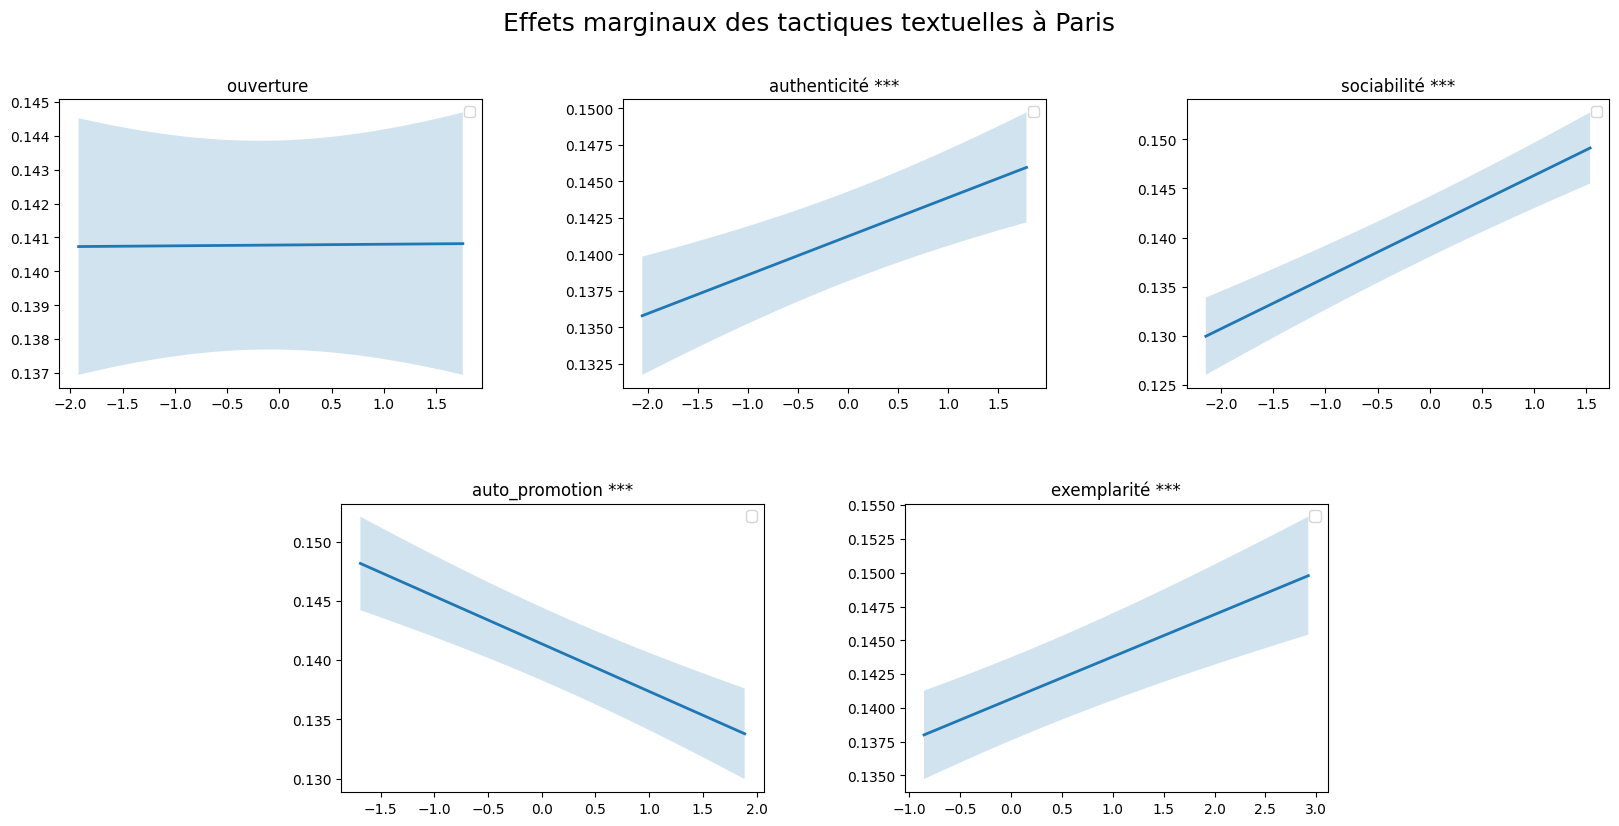

In [185]:
df=df_all.copy()
model=model_basic

# -------------------layout-------------------
# 使用更细的列分辨率（2 行 × 6 列），方便把第二行两个图放在中间列
fig = plt.figure(figsize=(20,9))
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.4, wspace=1)

axes = []
# 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])
axes.extend([ax1, ax2, ax3])

# 第二行两个：让它们居中，分别占中间的两列 (1:3 和 3:5)
ax4 = fig.add_subplot(gs[1, 1:3])
ax5 = fig.add_subplot(gs[1, 3:5])
axes.extend([ax4, ax5])

# 确保 tactics_vars 长度为 5（或小于等于 len(axes)）
n_to_plot = min(len(tactics_bio), len(axes))


# city='paris'
# times=['2024',"2023"]


for i, var in enumerate(tactics_bio):
    ax = axes[i]
    # for time in times:
    pred_df = plot_predict_curve(model, df, var)
    sig=p_to_sig(model.pvalues[var])
    ax.plot(pred_df[var], pred_df["y"], linewidth=2)
    ax.fill_between(pred_df[var], pred_df["low"], pred_df["high"], alpha=0.2)
    ax.legend()#on ax
    ax.set_title(f"{var} {sig}")

fig.suptitle(
        "Effets marginaux des tactiques textuelles à Paris",
        fontsize=18,
        y=0.98
    )
plt.tight_layout()
plt.show()

In [186]:
def plot_categorical_effect(model, df, var, sample_n=5000):
    import pandas as pd
    
    # 抽样（关键！）
    base = df.sample(sample_n, random_state=0).copy()
    
    categories = df[var].dropna().unique()
    
    results = []
    for cat in categories:
        print(cat)
        
        base[var] = cat
        yhat = model.predict(base)   # 🚀 快很多
        term=f"C({var})[T.{cat}]"
        
        if term not in list(model.params.index):
            sig = ""
        else:   
            sig = p_to_sig(float(model.pvalues[term]))
        
        
        results.append({
            "variable":var,
            "category": cat,
            "y": yhat.mean(),
            "sig": sig
        })
    return pd.DataFrame(results)

pred_df = plot_categorical_effect(model_basic, df, var="host_picture_type")
display(pred_df)


life_style
pro_style
no_person


,variable,category,y,sig
0,host_picture_type,life_style,0.116065,
1,host_picture_type,pro_style,0.118392,**
2,host_picture_type,no_person,0.109621,***


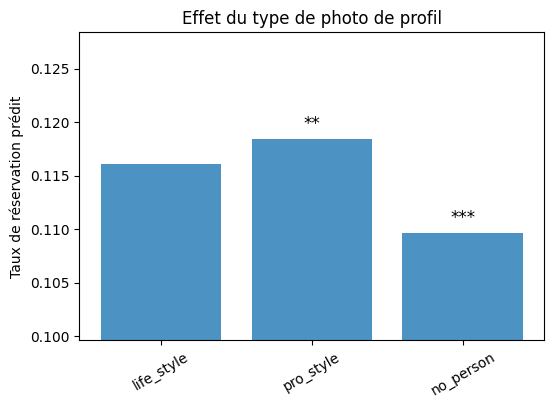

In [187]:
def plot_cat_effect(df_plot):
    import matplotlib.pyplot as plt

    plt.figure(figsize=(6,4))

    ax = plt.gca()

    ax.bar(df_plot["category"], df_plot["y"], alpha=0.8)

    for i, row in df_plot.iterrows():
        ax.text(i, row["y"] + 0.001, row["sig"],
                ha='center', fontsize=12)
    
    ax.set_ylabel("Taux de réservation prédit")
    ax.set_title("Effet du type de photo de profil")
    ax.tick_params(axis="x", rotation=30)

    plt.ylim(min(df_plot["y"]) - 0.01, max(df_plot["y"]) + 0.01)
    plt.show()
plot_cat_effect(pred_df)

f
t


,variable,category,y,sig
0,host_is_superhost,f,0.113674,
1,host_is_superhost,t,0.119241,***


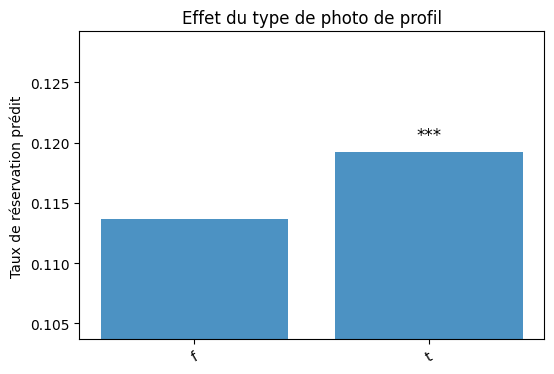

In [188]:

pred_df = plot_categorical_effect(model_basic, df, var="host_is_superhost")
display(pred_df)
plot_cat_effect(pred_df)


## model inetraction

In [7]:
df=df_all.copy()
formula= ("booking_rate_l90d ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
        "number_of_reviews_ltm + "
        "C(host_is_superhost) +"
        "years_since_host + professional_host + "
        "host_response_rate +  +C(host_response_time)+"
        "has_text + lang_en + lang_fr + text_length+"
        "price  + availability_90 + C(room_type) + C(instant_bookable) + "
        "C(host_picture_type) +"
        "C(time) +"
        "in_paris * C(time) *(C(host_picture_type) + ouverture + authenticité + sociabilité + auto_promotion + exemplarité)"
        # "pic_no_person + pic_pro_style + pic_life_style +"
        # " is_smiling + "
        # "C(age_class) + C(gender) +"

)
df=df_all.copy()
model_interaction=smf.ols(formula, data=df).fit()
summary=model_interaction.summary()
print(summary)

                            OLS Regression Results                            
Dep. Variable:      booking_rate_l90d   R-squared:                       0.402
Model:                            OLS   Adj. R-squared:                  0.402
Method:                 Least Squares   F-statistic:                     2601.
Date:                Thu, 09 Apr 2026   Prob (F-statistic):               0.00
Time:                        13:46:36   Log-Likelihood:                 89010.
No. Observations:              266852   AIC:                        -1.779e+05
Df Residuals:                  266782   BIC:                        -1.771e+05
Df Model:                          69                                         
Covariance Type:            nonrobust                                         
                                                                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------

### effets des tactiques dans les groups

In [ ]:
data_interaction={}
coefs=model_interaction.params.filter(like="authenticité")
se=model_interaction.bse.filter(like="authenticité")
pvalues=model_interaction.pvalues.filter(like="authenticité")
data_interaction={'coef':coefs,
                  "se":se,
                  "pval":pvalues}
display(pd.DataFrame(data_interaction).rename_axis("term").reset_index())


In [ ]:
import pandas as pd
## 


# 取系数
b0 = coefs["authenticité"]
b_t2312 = coefs.get("C(time)[T.2312]:authenticité", 0)
b_t2406 = coefs.get("C(time)[T.2406]:authenticité", 0)
b_paris = coefs.get("in_paris:authenticité", 0)
b_paris_2312 = coefs.get("in_paris:C(time)[T.2312]:authenticité", 0)
b_paris_2406 = coefs.get("in_paris:C(time)[T.2406]:authenticité", 0)

rows = []

# 非巴黎
rows.append(("2306", 0, b0))
rows.append(("2312", 0, b0 + b_t2312))
rows.append(("2406", 0, b0 + b_t2406))

# 巴黎
rows.append(("2306", 1, b0 + b_paris))
rows.append(("2312", 1, b0 + b_t2312 + b_paris + b_paris_2312))
rows.append(("2406", 1, b0 + b_t2406 + b_paris + b_paris_2406))

df_plot = pd.DataFrame(rows, columns=["time", "in_paris", "effect"])
df_plot


,time,in_paris,effect
0,2306,0,0.009019
1,2312,0,-0.005589
2,2406,0,0.003519
3,2306,1,0.013192
4,2312,1,0.000148
5,2406,1,-0.000873


: 

In [ ]:
# time, in_paris, coef, pval, 


In [ ]:
def manual_effect(model, tactic, time, is_paris):
    b = model.params

    base = b[f"{tactic}"]

    # time interaction
    time_term = f"{tactic}:C(time)[T.{time}]"
    time_eff = b[time_term] if time_term in b else 0

    if is_paris:
        paris_term = f"in_paris:{tactic}"
        paris_time_term = f"in_paris:C(time)[T.{time}]:{tactic}"

        paris_eff = b.get(paris_term, 0) + b.get(paris_time_term, 0)
    else:
        paris_eff = 0

    return base + time_eff + paris_eff

In [195]:
import numpy as np
import pandas as pd
from scipy.stats import norm

# -----------------------------
# 1. 生成 counterfactual 数据
# -----------------------------
def build_cf(df, in_paris, time, tactic, value):
    temp = df.copy()

    # city
    temp["in_paris"] = 1 if in_paris == "Paris" else 0

    # time
    temp["t"] = time

    # tactics reset
    tactics = [
        "ouverture",
        "authenticité",
        "sociabilité",
        "auto_promotion",
        "exemplarité"
    ]

    for t in tactics:
        temp[t] = 0

    temp[tactic] = value

    return temp


# -----------------------------
# 2. effect + bootstrap p-value
# -----------------------------
def compute_effect(model, df, city, time, tactic, B=50):

    effects = []

    for b in range(B):

        sample = df.sample(frac=1, replace=True)

        d0 = build_cf(sample, city, time, tactic, 0)
        d1 = build_cf(sample, city, time, tactic, 1)

        y0 = model.predict(d0).mean()
        y1 = model.predict(d1).mean()

        effects.append(y1 - y0)

    effects = np.array(effects)

    mean_eff = effects.mean()
    se = effects.std(ddof=1)

    z = mean_eff / se
    pval = 2 * (1 - norm.cdf(abs(z)))

    return mean_eff, pval


# -----------------------------
# 3. 主循环生成 df
# -----------------------------
def build_effect_table(model, df):

    tactics = [
        "ouverture",
        "authenticité",
        "sociabilité",
        "auto_promotion",
        "exemplarité"
    ]

    times = [2306, 2312, 2406]
    cities = ["London", "Paris"]

    results = []

    for city in cities:
        for time in times:
            for tactic in tactics:

                eff, pval = compute_effect(
                    model, df,
                    city=city,
                    time=time,
                    tactic=tactic,
                    B=30   # 可以调大 100 更稳
                )

                results.append({
                    "in_paris": 1 if city == "Paris" else 0,
                    "time": time,
                    "tactic": tactic,
                    "real_effect": eff,
                    "pval": pval
                })

    return pd.DataFrame(results)
model=model_interaction
df=df_all.copy()

df_results = build_effect_table(model, df)
df_results["sig"] = df_results["pval"].apply(p_to_sig)
df_results

ValueError: cannot reindex on an axis with duplicate labels

In [196]:
print(df.columns[df.columns.duplicated()])

Index([], dtype='object')


In [ ]:
def get_event_study_data_var(model):
    import numpy as np
    params = model.params
    bse = model.bse
    pvalues=model.pvalues
    
    # 提取 interaction terms
    data = pd.DataFrame({
        "coef": params,
        "se": bse,
        'pval':pvalues
    }).reset_index()

    data.columns = ["variable", "coef", "se", "pval"]
    
    # 只保留 in_paris × time
    data = data[data["variable"].str.contains(f"in_paris:C\\(time\\)")]
    # pattern = "|".join(tactics_bio)
    # data = data[data["variable"].str.contains(pattern)]
    
    
    # 提取时间点
    data["time"] = data["variable"].str.extract(r"T\.(\d+)")

    # 排序
    data = data.sort_values("time")

    # 置信区间
    data["ci_low"] = data["coef"] - 1.96 * data["se"]
    data["ci_high"] = data["coef"] + 1.96 * data["se"]
    
    # baseline（2306 = 0）
    baseline = pd.DataFrame({
        "time": ["2306"],
        "coef": [0],
        "ci_low": [0],
        "ci_high": [0]
    })


    data = pd.concat([baseline, data], ignore_index=True)

    # 转 numeric
    data["time"] = pd.to_numeric(data["time"])
    data = data.sort_values("time")
    data['time']=data['time'].astype(str)
    
    # display(data)
    data['tactic']= data['variable'].apply(lambda x : str(x).split(':')[-1] if x!=np.nan and str(x).split(':')[-1] in tactics_bio else np.nan)
    data['sig']=data['pval'].apply(p_to_sig)        
    data['label']=data['time']+' '+data['sig']        
    return data

data=get_event_study_data_var(model_interaction)
display(data)

,time,coef,ci_low,ci_high,variable,se,pval,tactic,sig,label
0,2306,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,,2306
1,2312,-0.028463,-0.032198,-0.024727,in_paris:C(time)[T.2312],0.001906,2.072115e-50,NaN,***,2312 ***
2,2312,0.004478,-0.001902,0.010858,in_paris:C(time)[T.2312]:ouverture,0.003255,1.689162e-01,ouverture,,2312
3,2312,0.000858,-0.005524,0.007240,in_paris:C(time)[T.2312]:authenticité,0.003256,7.921549e-01,authenticité,,2312
4,2312,-0.007041,-0.013237,-0.000845,in_paris:C(time)[T.2312]:sociabilité,0.003161,2.592578e-02,sociabilité,*,2312 *
5,2312,0.010291,0.003887,0.016695,in_paris:C(time)[T.2312]:auto_promotion,0.003267,1.634425e-03,auto_promotion,**,2312 **
6,2312,-0.004604,-0.010560,0.001352,in_paris:C(time)[T.2312]:exemplarité,0.003039,1.297540e-01,exemplarité,,2312
7,2406,-0.060458,-0.063947,-0.056969,in_paris:C(time)[T.2406],0.001780,2.931487e-252,NaN,***,2406 ***
8,2406,0.001352,-0.004549,0.007253,in_paris:C(time)[T.2406]:ouverture,0.003011,6.534620e-01,ouverture,,2406
9,2406,-0.010612,-0.016548,-0.004676,in_paris:C(time)[T.2406]:authenticité,0.003029,4.584949e-04,authenticité,***,2406 ***


In [ ]:
## PARAMS
res = model_interaction
params = res.params
cov = res.cov_params()
strategies = ["ouverture", "authenticité", "sociabilité", "auto_promotion", "exemplarité"]
times = ["2306", '2312', "2406"]


In [ ]:
import pandas as pd
import numpy as np

def get_effect(res, strategy, time):

    base = f"{strategy}"
    t = f"C(time)[T.{time}]:{strategy}"
    p = f"in_paris:C(time)[T.{time}]:{strategy}"

    coef = 0
    var = 0

    terms = []
    
    # 找到三个相关term的coef
    for term in [base, t, p]:
        if term in res.params.index:
            coef += res.params[term]
            terms.append(term)

    # variance (Delta method)
    for i in terms:
        for j in terms:
            if i in res.params.index and j in res.params.index:
                var += res.cov_params().loc[i, j]

    se = np.sqrt(var)

    return coef, se

In [ ]:
rows = []
for s in strategies:
    for t in times:
        # print(s, t)
        coef, se = get_effect(res, s, t)

        rows.append({
            "variable": s,
            "time": t,
            "effect": coef,
            "se": se,
            "ci_low": coef - 1.96*se,
            "ci_high": coef + 1.96*se
        })
    #     break
    # break

df_plot = pd.DataFrame(rows)
df_plot

,variable,time,effect,se,ci_low,ci_high
0,ouverture,2306,0.000466,0.001501,-0.002477,0.003409
1,ouverture,2312,0.004608,0.002880,-0.001037,0.010252
2,ouverture,2406,0.004178,0.002650,-0.001016,0.009373
3,authenticité,2306,0.011157,0.001500,0.008217,0.014096
4,authenticité,2312,-0.006947,0.002888,-0.012608,-0.001286
5,authenticité,2406,-0.007376,0.002683,-0.012635,-0.002117
6,sociabilité,2306,0.010051,0.001399,0.007309,0.012793
7,sociabilité,2312,-0.006222,0.002833,-0.011774,-0.000670
8,sociabilité,2406,-0.007355,0.002607,-0.012465,-0.002245
9,auto_promotion,2306,-0.008856,0.001461,-0.011718,-0.005993


C:\Users\yeliu\AppData\Local\Temp\ipykernel_20272\1416556135.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


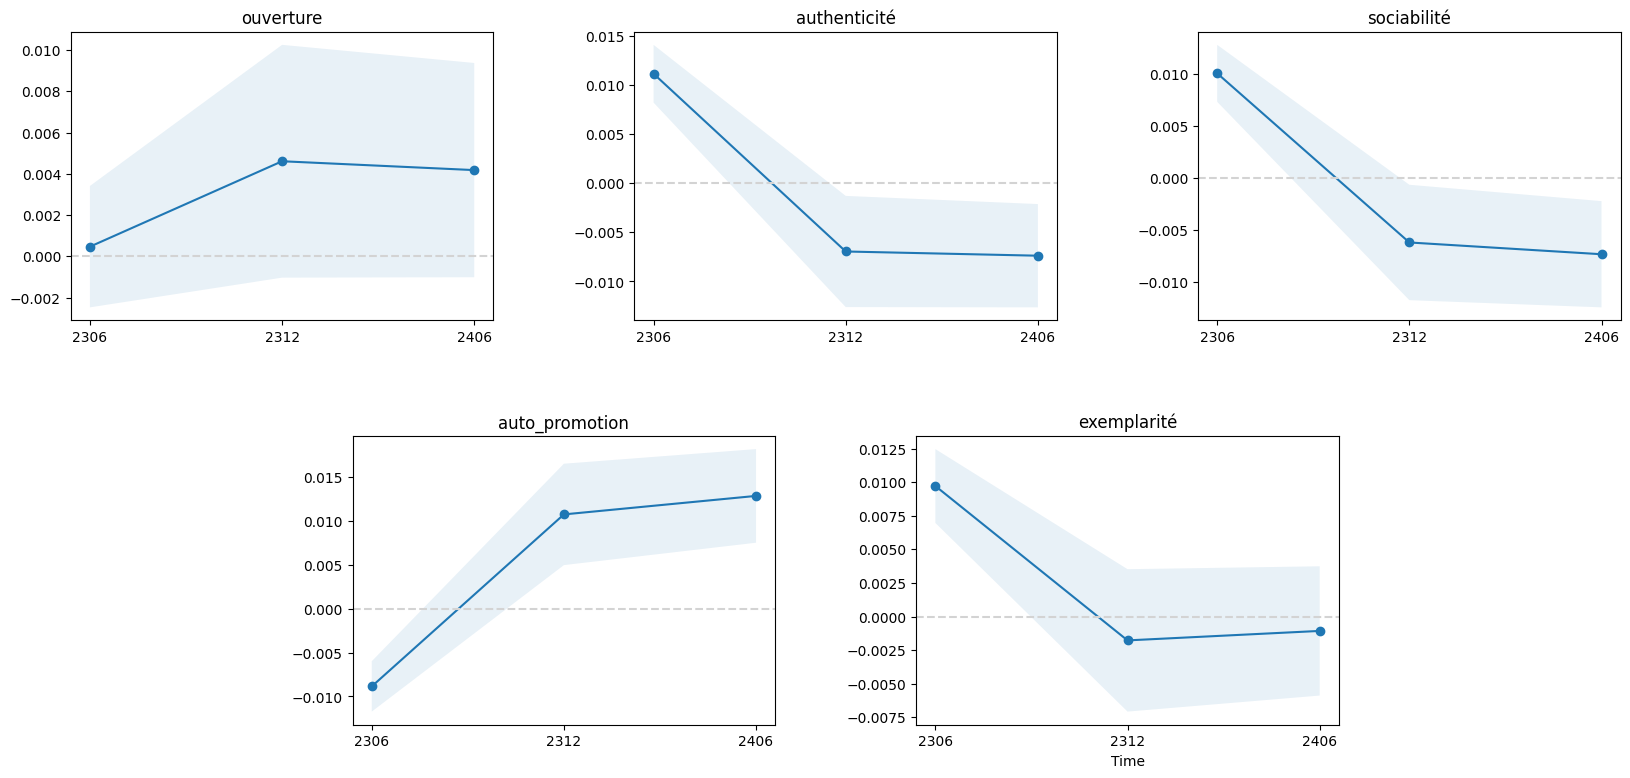

In [ ]:
#👉 Paris 相对于 London，在每个 time 下 strategy 的边际效应
# ❗ JO 是否改变“策略 → 预订率”的回报结构？
# Effect k,t ​= βstrategy,k ​+ βtime × strategy ​+ βinparis × time × strategy​


import matplotlib.pyplot as plt
import seaborn as sns

def plot_strategy_multiples(df):
    df['time']=df['time'].astype(str)
    vars = df["variable"].unique()

    
    # ---layout---
    # 使用更细的列分辨率（2 行 × 6 列），方便把第二行两个图放在中间列
    fig = plt.figure(figsize=(20,9))# sharey=True
    gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.4, wspace=1)

    axes = []
    # 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
    ax1 = fig.add_subplot(gs[0, 0:2])
    ax2 = fig.add_subplot(gs[0, 2:4])
    ax3 = fig.add_subplot(gs[0, 4:6])
    axes.extend([ax1, ax2, ax3])

    # 第二行两个：让它们居中，分别占中间的两列 (1:3 和 3:5)
    ax4 = fig.add_subplot(gs[1, 1:3])
    ax5 = fig.add_subplot(gs[1, 3:5])
    axes.extend([ax4, ax5])

    for i, var in enumerate(vars):
        sub = df[df["variable"] == var]#.sort_values("time")
         
        # display(sub)
        ax = axes[i]

        # line
        ax.plot(sub["time"], sub["effect"], marker="o")

        # CI band
        ax.fill_between(
            sub["time"],
            sub["ci_low"],
            sub["ci_high"],
            alpha=0.1
        )

        # 标题
        ax.set_title(var)

        # JO 标记
        # ax.axvline("2406", linestyle="--")
        # ax.text("2406", ax.get_ylim()[1]*0.9, "JO")

        ax.axhline(0, linestyle="--", color="lightgray")
        # break
    
    plt.xlabel("Temps")
    plt.tight_layout()
    plt.show()
    
    
plot_strategy_multiples(df_plot)